%pip install -U -q numpy pandas wfdb matplotlib notebook scikit-learn PyWavelets

In [4]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.linear_model import LinearRegression

import funkcje
from processor import Signal, ICP_ABP_Processor

In [5]:
#MAJA I MANIA DETEKCJA EVENTÓW

## Sekcja wczytwania


Rekord: charis1
Długość: 12239851 próbek (68.0 h)
fs: 50 Hz, Kanały: 3
Nazwy kanałów: ['ABP', 'ECG', 'ICP']
[ICP] Szumy usunięte.
[ABP] Szumy usunięte.
[ICP] Sygnał przefiltrowany.
[ABP] Sygnał przefiltrowany.


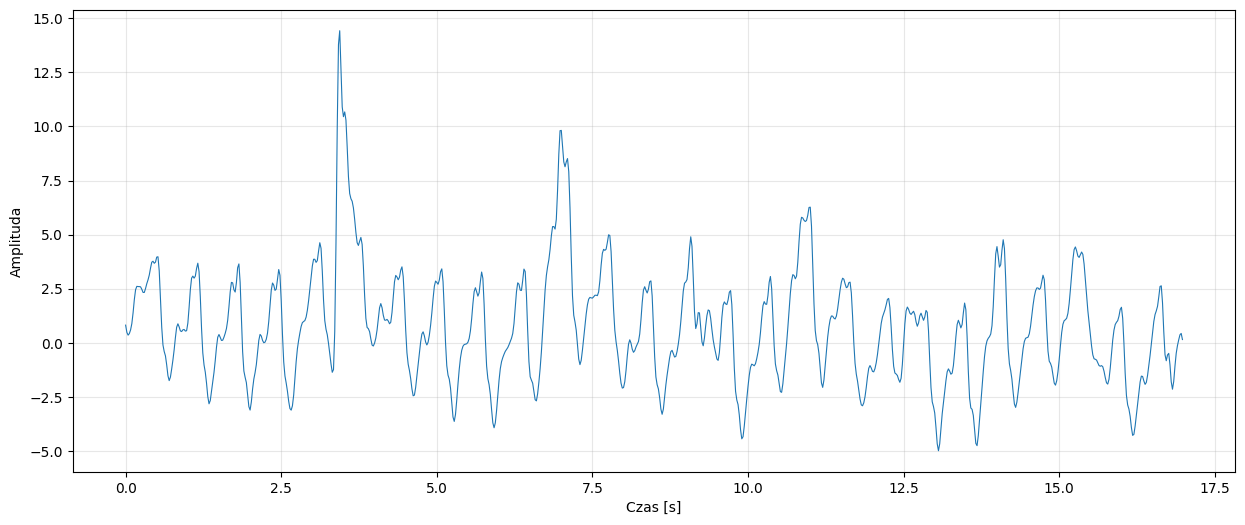

In [6]:
data_dir = 'charis-database-1.0.0'  # Lokalny folder
record_name = 'charis1'     # Nazwa rekordu (.hea i .dat)

os.makedirs(data_dir, exist_ok=True)

# TERAZ TWÓJ KOD BEZ ZMIAN
local_path = os.path.join(data_dir, record_name)

# Odczyt (automatycznie znajdzie .hea i .dat)
record = wfdb.rdrecord(local_path)

# Dane sygnałów
signals = record.p_signal  # NxM tablica (próbki x kanały)
fs = record.fs  # Częstotliwość próbkowania
time = np.arange(len(signals)) / fs # sekundy

print(f"Rekord: {record_name}")
print(f"Długość: {len(signals)} próbek ({len(signals)/fs/3600:.1f} h)")
print(f"fs: {fs} Hz, Kanały: {record.n_sig}")
print(f"Nazwy kanałów: {record.sig_name}")  # ['ABP', 'ECG', 'ICP']


channel_ABP = signals[:,0]
channel_ICP = signals[:,2]

# Inicjalizacja
processor = ICP_ABP_Processor(channel_ICP, channel_ABP, sampling_freq=50)
processor.process_all()

# # Pobieranie okien do dalszej analizy (np. korelacji PRx)
# okna_icp, okna_abp = processor.get_windowed_data(x_seconds_avg=5, window_size=60)
# PRx = calculate_PRx()


# Wizualizacja pierwszych 60s
plt.figure(figsize=(15, 6))
plt.plot(time[:int(17*fs)], processor.icp.data[:int(17*fs)], linewidth=0.8)
plt.xlabel('Czas [s]')
plt.ylabel('Amplituda')
#plt.title(f'{record_name} kanał {record.sig_name[channel]}')
plt.grid(True, alpha=0.3)
plt.show()

# Zapis do CSV (opcjonalnie)
# np.savetxt('ecg_data.csv', np.column_stack([time, ecg]), delimiter=',', 
#            header='time_s,ecg_mv', comments='')


Rekord: charis2
Długość: 67499794 próbek (375.0 h)
fs: 50 Hz, Kanały: 3
Nazwy kanałów: ['ABP', 'ECG', 'ICP']
Etap 1-3: Podział na 1-minutowe segmenty i obliczanie średnich (MABP, MICP)...
Etap 4: Detekcja i usuwanie zakłóceń (>50 mmHg)...
Etap 5: Detekcja zdarzeń (>25 mmHg przez min. 5 min)...
Etap 6: Ekstrakcja segmentów (1h prawidłowego sygnału przed + zdarzenie)...
--> Zakończono! Znaleziono 242 spełniających kryteria segmentów.


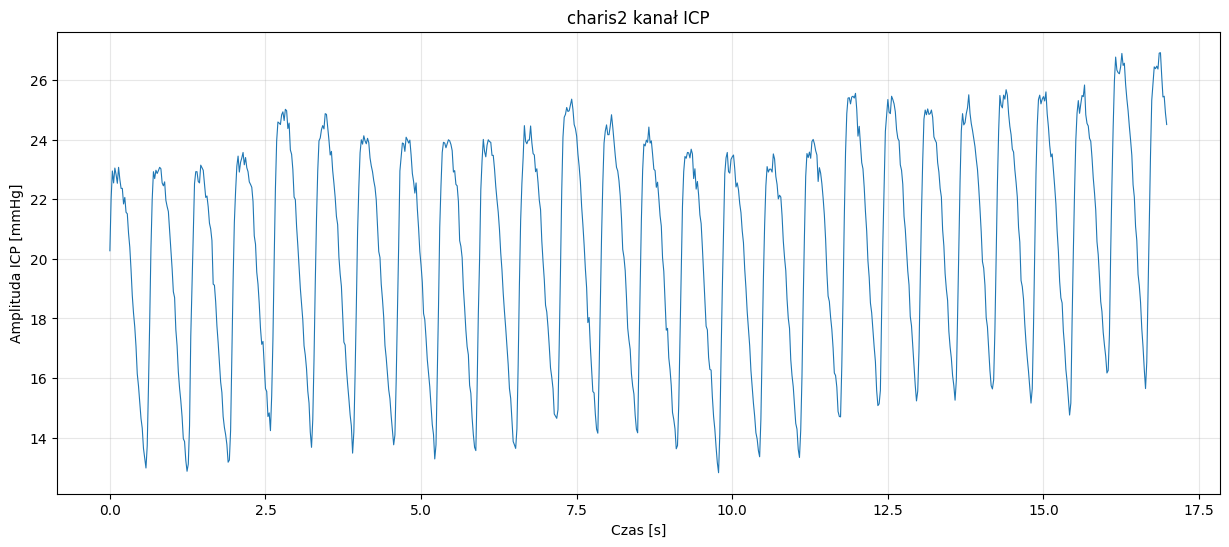

In [2]:
import os
import wfdb
import numpy as np
import matplotlib.pyplot as plt

# --- POMOCNICZA KLASA DO OPAKOWANIA DANYCH ---
class SignalWrapper:
    def __init__(self, data):
        self.data = data

# --- GŁÓWNA KLASA PRZETWARZAJĄCA (IMPLEMENTACJA SCHEMATU) ---
class ICP_ABP_Processor:
    def __init__(self, channel_icp, channel_abp, sampling_freq):
        # Opakowanie sygnałów, aby pasowały do wywołania processor.icp.data
        self.icp = SignalWrapper(channel_icp)
        self.abp = SignalWrapper(channel_abp)
        self.fs = sampling_freq
        
        # 1 minuta = częstotliwość próbkowania * 60 sekund
        self.samples_per_min = int(self.fs * 60)
        
        # Tablice na wyniki poszczególnych etapów
        self.mabp = []
        self.micp = []
        self.valid_mask = []
        self.events = []
        self.final_segments = []

    def process_all(self):
        print("Etap 1-3: Podział na 1-minutowe segmenty i obliczanie średnich (MABP, MICP)...")
        self._calculate_means()
        
        print("Etap 4: Detekcja i usuwanie zakłóceń (>50 mmHg)...")
        self._remove_artifacts()
        
        print("Etap 5: Detekcja zdarzeń (>25 mmHg przez min. 5 min)...")
        self._detect_events()
        
        print("Etap 6: Ekstrakcja segmentów (1h prawidłowego sygnału przed + zdarzenie)...")
        self._extract_segments()

    def _calculate_means(self):
        """Kroki 1, 2 i 3 z diagramu."""
        num_segments = len(self.icp.data) // self.samples_per_min
        
        self.mabp = np.zeros(num_segments)
        self.micp = np.zeros(num_segments)
        
        for i in range(num_segments):
            start = i * self.samples_per_min
            end = start + self.samples_per_min
            
            # Obliczenie średnich dla każdej minuty
            self.mabp[i] = np.mean(self.abp.data[start:end])
            self.micp[i] = np.mean(self.icp.data[start:end])
            
        # Domyślnie wszystkie segmenty uznajemy za prawidłowe (True)
        self.valid_mask = np.ones(num_segments, dtype=bool)

    def _remove_artifacts(self):
        """Krok 4: Detekcja i usunięcie zakłóceń czujników."""
        # Odfiltrowujemy segmenty gdzie średnia ICP przekracza 50 mmHg.
        # Dodałem opcjonalnie limity dla ABP (np. > 200), co często też robi się w praktyce.
        artifact_mask = (self.micp > 50) | (self.mabp > 200) | (self.mabp < 20)
        self.valid_mask[artifact_mask] = False

    def _detect_events(self):
        """Krok 5: Detekcja zdarzeń (>25 mmHg przez co najmniej 5 min)."""
        threshold = 25
        required_duration = 5 # 5 segmentów = 5 minut
        
        consecutive_mins = 0
        in_event = False
        event_start = 0
        
        for i in range(len(self.micp)):
            # Warunek wejścia w zdarzenie: prawidłowy sygnał ORAZ MICP > 25
            if self.valid_mask[i] and self.micp[i] > threshold:
                if not in_event:
                    event_start = i
                    in_event = True
                consecutive_mins += 1
            else:
                # Zakończenie zdarzenia lub przerwanie serii
                if in_event and consecutive_mins >= required_duration:
                    self.events.append((event_start, i - 1)) # Zapisz (start, koniec) zdarzenia
                in_event = False
                consecutive_mins = 0
                
        # Sprawdzenie czy zdarzenie nie trwało do samego końca zapisu
        if in_event and consecutive_mins >= required_duration:
            self.events.append((event_start, len(self.micp) - 1))

    def _extract_segments(self):
        """Krok 6: Podział na segmenty (1h prawidłowego sygnału + zdarzenie)."""
        required_pre_event = 60 # 60 minut = 1 godzina
        
        for ev_start, ev_end in self.events:
            if ev_start >= required_pre_event:
                pre_event_start = ev_start - required_pre_event
                
                # Sprawdzamy czy cała poprzedzająca godzina (60 min) ma prawidłowy sygnał
                if np.all(self.valid_mask[pre_event_start:ev_start]):
                    self.final_segments.append({
                        'pre_event_start_min': pre_event_start,
                        'event_start_min': ev_start,
                        'event_end_min': ev_end
                    })
                    
        print(f"--> Zakończono! Znaleziono {len(self.final_segments)} spełniających kryteria segmentów.")

    def get_windowed_data(self, x_seconds_avg=5, window_size=60):
        """Metoda-zaślepka (placeholder) na podstawie zakomentowanego kodu."""
        print(f"Pobieranie okien danych: średnia z {x_seconds_avg}s, rozmiar okna: {window_size}s...")
        # Tutaj w przyszłości można dodać logikę do obliczania PRx/RAP
        return [], []


# --- TWOJA SEKCJA KODU ŁADUJĄCEGO DANE ---
data_dir = 'charis-database-1.0.0'  # Lokalny folder
record_name = 'charis2'             # Nazwa rekordu (.hea i .dat)

os.makedirs(data_dir, exist_ok=True)
local_path = os.path.join(data_dir, record_name)

try:
    # Odczyt (automatycznie znajdzie .hea i .dat)
    record = wfdb.rdrecord(local_path)

    # Dane sygnałów
    signals = record.p_signal  # NxM tablica (próbki x kanały)
    fs = record.fs  # Częstotliwość próbkowania
    time = np.arange(len(signals)) / fs # sekundy

    print(f"Rekord: {record_name}")
    print(f"Długość: {len(signals)} próbek ({len(signals)/fs/3600:.1f} h)")
    print(f"fs: {fs} Hz, Kanały: {record.n_sig}")
    print(f"Nazwy kanałów: {record.sig_name}")  # ['ABP', 'ECG', 'ICP']

    channel_ABP = signals[:, 0]
    channel_ICP = signals[:, 2]

    # Inicjalizacja
    processor = ICP_ABP_Processor(channel_ICP, channel_ABP, sampling_freq=fs)
    processor.process_all()

    # Wizualizacja pierwszych 17s
    plt.figure(figsize=(15, 6))
    plt.plot(time[:int(17*fs)], processor.icp.data[:int(17*fs)], linewidth=0.8)
    plt.xlabel('Czas [s]')
    plt.ylabel('Amplituda ICP [mmHg]')
    plt.title(f'{record_name} kanał ICP')
    plt.grid(True, alpha=0.3)
    plt.show()

except FileNotFoundError:
    print(f"Błąd: Nie znaleziono plików rekordu '{record_name}' w katalogu '{data_dir}'. Pobierz zbiór danych.")